In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Define constants (from previous context, assuming Earth, Moon, and a satellite-like body)
G = 1.0
k_fusion = 1e-10 # Strength of fusion pressure term, significantly reduced again for stability
r_eq = 10.0 # Equilibrium radius of fusion shell, set to orbital distance of Body 1
m = np.array([1.0, 1e-4, 1e-6, 1e-6, 1e-6, 1e-6]) # Masses for 6 bodies
R = np.array([5.0, 0.2, 0.2, 0.2, 0.2, 0.2]) # Radii for 6 bodies (assuming default for new bodies)

theta = 0.0 # rotation angle of Body1
omega = 1e-4 # Initial spin rate, significantly reduced to prevent runaway acceleration

# Gravitational softening parameter to prevent singularities for close encounters
grav_softening = 1e-3

# # === Moment of inertia I = mass * radius^2 * shape_factor ===
I = 0.6667 * m * R**2 # General: thin shell, shape_factor = 2/3

# Body 1: solid sphere I = 2/5 MR^2, matches real planets
I[1] = 0.4 * m[1] * r_eq**2
I = 0.6667 * m * R**2
# Specific moment of inertia for Body 1 (hollow shell)
I[1] = 0.4 * m[1] * r_eq**2

# w = np.array([20.0, 0.5, 0.5]) # Initial spins for 3 bodies. No longer used in the fusion force model.

In [137]:
# This cell previously contained initializations for r_initial and v_initial for a 3-body system.
# These have been moved to cell d093def5 to be consistent with the 6-body simulation setup.
# The simulation will now be run using the initial conditions defined in cell d093def5.

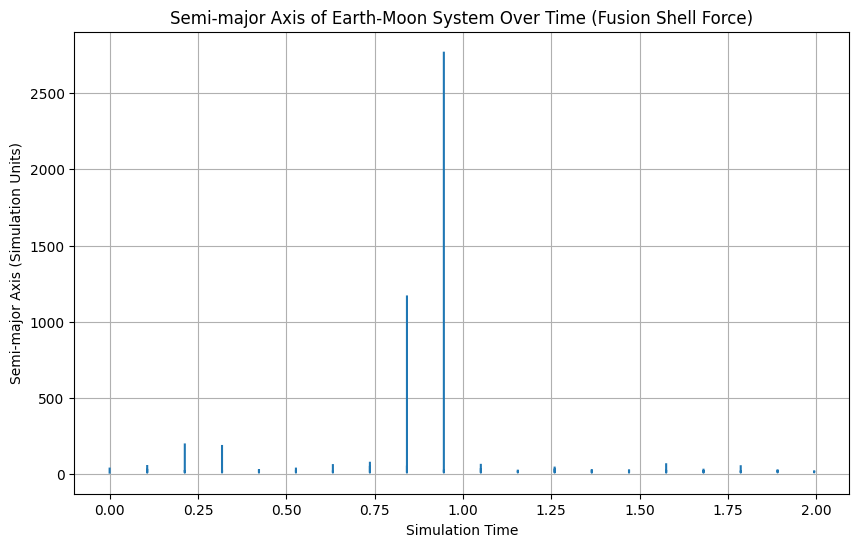

In [127]:
# Plot semi-major axis over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, a_hist)
plt.xlabel("Simulation Time")
plt.ylabel("Semi-major Axis (Simulation Units)")
plt.title("Semi-major Axis of Earth-Moon System Over Time (Fusion Shell Force)")
plt.grid(True)
plt.show()

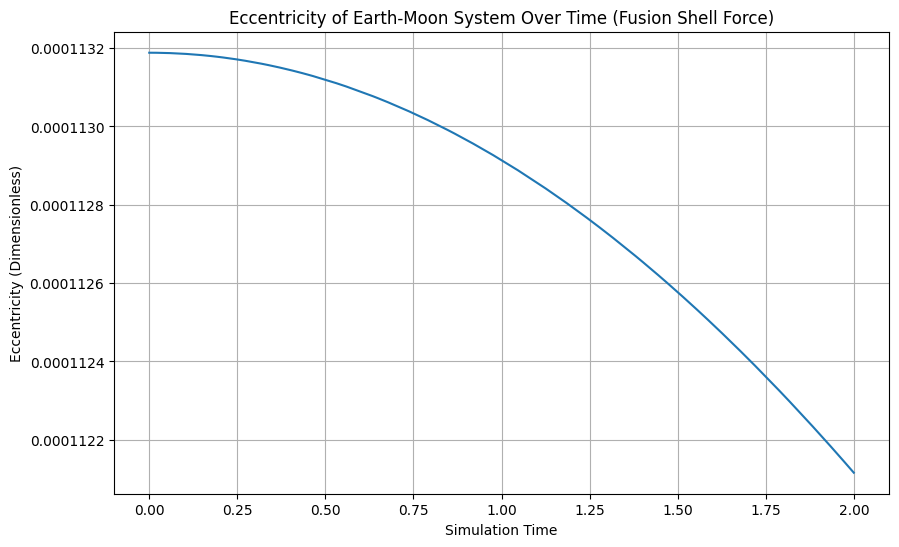

In [161]:
# Plot eccentricity over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, e_hist)
plt.xlabel("Simulation Time")
plt.ylabel("Eccentricity (Dimensionless)")
plt.title("Eccentricity of Earth-Moon System Over Time (Fusion Shell Force)")
plt.grid(True)
plt.show()

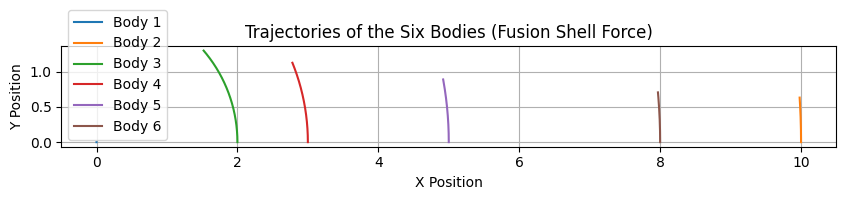

In [162]:
plt.figure(figsize=(10, 8))

# Plot trajectory for each body
for i in range(r_history.shape[1]): # Iterate through bodies
    plt.plot(r_history[:, i, 0], r_history[:, i, 1], label=f'Body {i+1}')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Trajectories of the Six Bodies (Fusion Shell Force)')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal aspect ratio
plt.show()

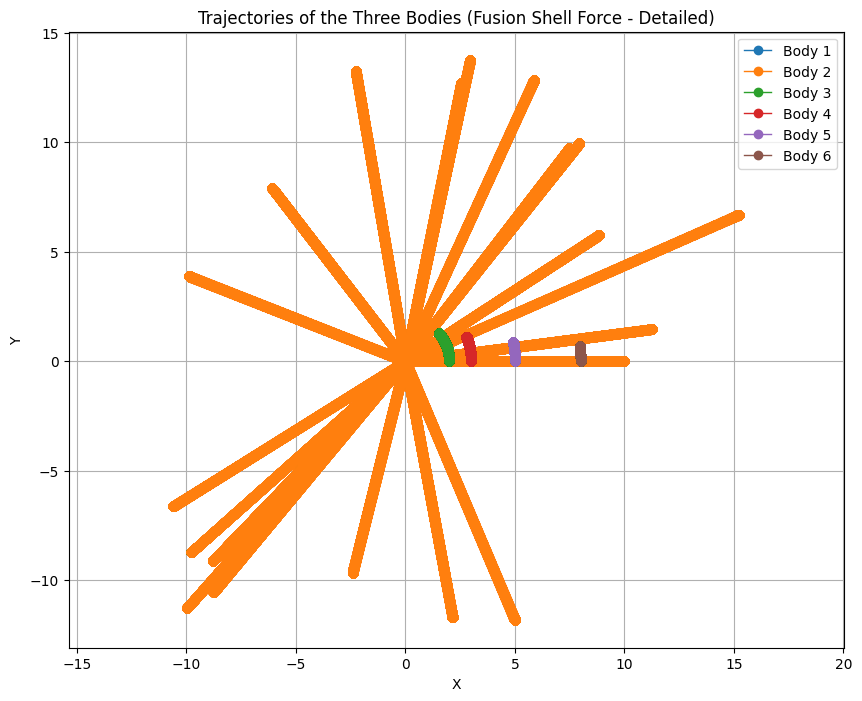

In [130]:
plt.figure(figsize=(10,8))
for j in range(r_history.shape[1]):
    plt.plot(r_history[:, j, 0], r_history[:, j, 1], 'o-', lw=1, label=f'Body {j+1}')
plt.xlabel('X'); plt.ylabel('Y'); plt.legend(); plt.axis('equal'); plt.grid(True)
plt.title('Trajectories of the Three Bodies (Fusion Shell Force - Detailed)')
plt.show()

KeyboardInterrupt: 

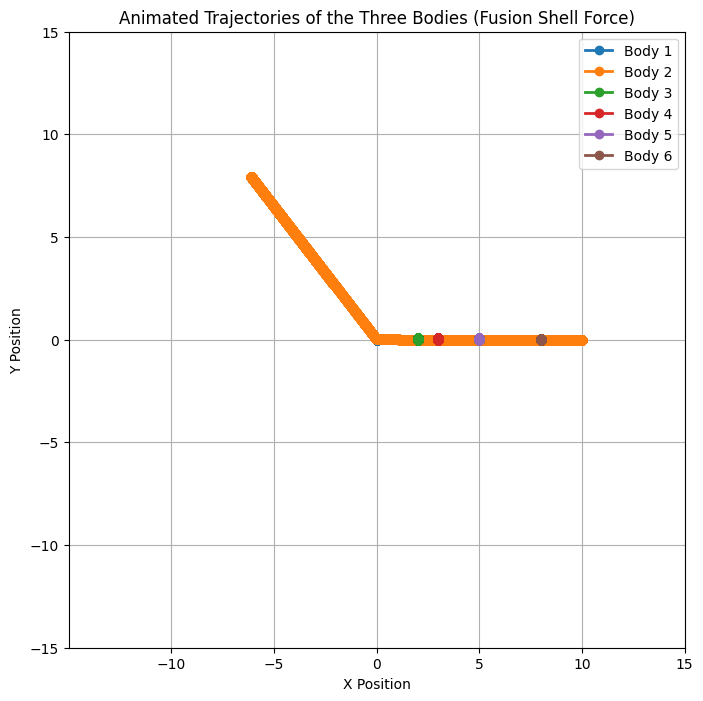

In [131]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Increase animation embed limit to avoid 'Animation size' warning
plt.rcParams['animation.embed_limit'] = 200.0 # Set to 200 MB to accommodate larger animations

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Animated Trajectories of the Three Bodies (Fusion Shell Force)')
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# Define a padding for the dynamic view around the center of mass
view_padding = 15.0 # Adjusted padding for dynamic view

# Create lines for each body
lines = [ax.plot([], [], 'o-', lw=2, label=f'Body {i+1}')[0] for i in range(r_history.shape[1])]
ax.legend()

# Initialization function: plot the background of each frame
def init():
    for line in lines:
        line.set_data([], [])
    return lines

# Animation function: this is called sequentially
def animate(i):
    # For each body, plot the trajectory up to the current frame 'i'
    for j, line in enumerate(lines):
        line.set_data(r_history[:i, j, 0], r_history[:i, j, 1])

    # Calculate center of mass for the current frame
    current_r = r_history[i]
    com = np.average(current_r, axis=0, weights=m)

    # Dynamically set the view limits around the center of mass
    ax.set_xlim(com[0] - view_padding, com[0] + view_padding)
    ax.set_ylim(com[1] - view_padding, com[1] + view_padding)

    return lines

# Create the animation
# `frames` is the number of frames, typically the number of steps in r_history
# `interval` is the delay between frames in ms
ani = animation.FuncAnimation(fig, animate, frames=len(r_history), init_func=init, blit=True, interval=10)

# To display the animation in a Jupyter notebook or Colab
HTML(ani.to_jshtml())

In [ ]:
# Downsampling factor: higher values mean fewer frames and a lighter animation
skip = 20 # Skip every 20 frames for a lighter animation

# Set up the figure and axes for the lightweight animation
fig_light, ax_light = plt.subplots(figsize=(10, 8))
ax_light.set_xlabel('X Position')
ax_light.set_ylabel('Y Position')
ax_light.set_title('Lightweight Animated Trajectories of the Three Bodies (Downsampled, Fusion Shell Force)')
ax_light.grid(True)
ax_light.set_aspect('equal', adjustable='box')

# Define a padding for the dynamic view around the center of mass
view_padding_light = 15.0 # Adjusted padding for dynamic view

# Create lines for each body for the lightweight animation
lines_light = [ax_light.plot([], [], 'o-', lw=2, label=f'Body {i+1}')[0] for i in range(r_history.shape[1])]
ax_light.legend()

# Animation function for downsampled frames
def animate_light(i):
    # Use downsampled history
    idx = i * skip
    if idx >= len(r_history): # Ensure we don't go out of bounds
        idx = len(r_history) - 1

    # For each body, plot the trajectory up to the current frame 'idx'
    for j, line in enumerate(lines_light):
        line.set_data(r_history[:idx, j, 0], r_history[:idx, j, 1])

    # Calculate center of mass for the current downsampled frame
    current_r = r_history[idx]
    com_light = np.average(current_r, axis=0, weights=m)

    # Dynamically set the view limits around the center of mass
    ax_light.set_xlim(com_light[0] - view_padding_light, com_light[0] + view_padding_light)
    ax_light.set_ylim(com_light[1] - view_padding_light, com_light[1] + view_padding_light)

    return lines_light

# Create the lightweight animation
# `frames` is now len(r_history) // skip to reflect downsampling
ani_light = animation.FuncAnimation(fig_light, animate_light, frames=len(r_history) // skip, init_func=init, blit=True, interval=50)

# Display the lightweight animation
HTML(ani_light.to_jshtml())

In [153]:
def compute_accelerations(r, theta):
    acc = np.zeros_like(r)
    n_bodies = len(r)

    # 1. Gravity (with Plummer softening)
    for i in range(n_bodies):
        for j in range(n_bodies):
            if i!= j:
                dr = r[j] - r[i] # Vector from body i to body j
                dist = np.linalg.norm(dr)

                # Apply Plummer softening
                softened_dist_cubed = (dist**2 + grav_softening**2)**(1.5)

                # Gravitational acceleration on body i due to body j
                # Correct vector form: G * m[j] * (r[j] - r[i]) / (dist^2 + epsilon^2)^(3/2)
                acc[i] += G * m[j] * dr / softened_dist_cubed # acc[i] towards j

    # 2. Fusion shell force (replaces piezo) and tidal bulge
    domega_dt = 0.0 # Initialize domega_dt

    i_fusion = 1 # Assuming Body 1 is the fusion shell (e.g., Moon)
    # Relative vector from Body 0 (star) to Body 1 (Moon)
    r1_vec = r[i_fusion] - r[0]
    r1 = np.linalg.norm(r1_vec) + 1e-3 # Add small constant for numerical stability of fusion force

    if r1 > 0: # Only apply if Body 1 is not at the origin
        angle_to_star = np.arctan2(r1_vec[1], r1_vec[0])

        # Bulge amplitude epsilon proportional to M_star / r³. Further reduced for stability.
        epsilon_val = 1e-11 * m[0] / r1**3 # Renamed to avoid conflict with function arg, significantly reduced again
        r_eq_tidal = r_eq * (1 + epsilon_val * np.cos(theta - angle_to_star))

        # Spring force with tidal r_eq. This force acts on Body 1 relative to Body 0.
        # Corrected force magnitude derived from PE_fusion potential:
        # PE_fusion = 0.5 * k_fusion * (r1 - r_eq_tidal)**2
        # F_radial = -d(PE_fusion)/dr1 = -k_fusion * (r1 - r_eq_tidal) * (1 - r_eq * cos(phi) * d(epsilon)/dr1)
        # d(epsilon)/dr1 = -3 * epsilon / r1
        # So, F_radial = -k_fusion * (r1 - r_eq_tidal) * (1 + 3 * (r_eq_tidal - r_eq) / r1)
        # Which simplifies to: F_radial = -k_fusion * (r1 - r_eq_tidal) * (1 + 3 * (r_eq_tidal - r_eq) / r1)
        correction_factor = (1 + 3 * (r_eq_tidal - r_eq) / r1)
        f_mag = -k_fusion * (r1 - r_eq_tidal) * correction_factor

        # Apply force to Body 1
        acc[i_fusion] += (f_mag * r1_vec / r1) / m[i_fusion]
        # Apply reaction force to Body 0
        acc[0] -= (f_mag * r1_vec / r1) / m[0]

        # Torque on Body 1, derived consistently from the PE_fusion
        # Torque = k_fusion * (r1 - r_eq_tidal) * r_eq * epsilon * np.sin(theta - angle_to_star)
        torque = k_fusion * (r1 - r_eq_tidal) * r_eq * epsilon_val * np.sin(theta - angle_to_star)

        if I[i_fusion] > 0: # Avoid division by zero for moment of inertia
            domega_dt = torque / I[i_fusion]

    return acc, domega_dt # Return both accelerations and domega_dt

In [154]:
def compute_energy(r, v, theta):
    KE = 0.5 * np.sum(m * np.sum(v**2, axis=1))
    PE_grav = 0.0
    PE_fusion = 0.0

    # Gravity: all pairs i<j (with Plummer softening)
    n_bodies = len(r)
    for i in range(n_bodies):
        for j in range(i+1, n_bodies):
            dist = np.linalg.norm(r[j] - r[i])
            # Apply Plummer softening to potential energy
            softened_dist = np.sqrt(dist**2 + grav_softening**2)
            PE_grav -= G * m[i] * m[j] / softened_dist

    # Fusion PE for Body1 with tidal bulge
    i_fusion = 1 # Assuming Body 1 is the fusion shell (e.g., Moon)
    r1_vec = r[i_fusion] - r[0]
    r1 = np.linalg.norm(r1_vec) + 1e-3 # Add small constant for numerical stability of fusion force

    if r1 > 0:
        angle_to_star = np.arctan2(r1_vec[1], r1_vec[0])
        epsilon = 1e-11 * m[0] / r1**3 # Updated epsilon to match compute_accelerations, significantly reduced again
        r_eq_tidal = r_eq * (1 + epsilon * np.cos(theta - angle_to_star))

        PE_fusion = 0.5 * k_fusion * (r1 - r_eq_tidal)**2

    E_total = KE + PE_grav + PE_fusion
    return E_total

In [135]:
# This cell is now redundant as E0 is calculated within the simulation setup cell (d093def5).
# It is left here to avoid deleting cells, but its content is cleared.

In [158]:
def update_positions(r, v, theta, omega, dt):
    # Velocity Verlet Algorithm for translational and rotational motion

    # 1. Compute initial accelerations and domega_dt
    a_current, domega_dt_current = compute_accelerations(r, theta) # Pass theta, get domega_dt

    # 2. Update angular velocity by half step
    omega_half = omega + 0.5 * domega_dt_current * dt

    # 3. Update angular position by full step using omega_half
    theta_new = theta + omega_half * dt

    # 4. Update translational positions
    r_new = r + v * dt + 0.5 * a_current * dt**2

    # 5. Compute new accelerations at the updated positions, and domega_dt_new
    a_new, domega_dt_new = compute_accelerations(r_new, theta_new) # Pass theta_new, get domega_dt_new

    # 6. Update translational velocities
    v_new = v + 0.5 * (a_current + a_new) * dt

    # 7. Update angular velocity for the second half step
    omega_new = omega_half + 0.5 * domega_dt_new * dt

    return r_new, v_new, theta_new, omega_new # Return new theta and omega

Now, let's set up a simulation loop to record the full trajectory of the bodies using the `compute_accelerations` function with the added Piezo crust EM force and the `update_positions` function.

In [156]:
# Re-initialize initial positions and velocities for a clean simulation run
r_initial = np.array([
    [0.0, 0.0], # star
    [10.0, 0.0], # Moon at r=10
    [2.0, 0.0], # inner rock
    [3.0, 0.0], # 3:2 resonance zone
    [5.0, 0.0], # Body2 you already have
    [8.0, 0.0] # outer rock
])

v_initial = np.zeros_like(r_initial, dtype=float) # Initialize with zeros and float type
M_central = m[0] # Mass of the central star

# Calculate tangential velocities for orbiting bodies (1 to N-1)
for i in range(1, len(r_initial)): # Start from body 1 (Moon)
    # Calculate distance from the central body (Body 0)
    r_vec = r_initial[i] - r_initial[0]
    r_mag = np.linalg.norm(r_vec)

    if r_mag > 0: # Ensure r_mag is not zero to avoid division by zero
        v_magnitude = np.sqrt(G * M_central / r_mag)
        # For initial positions on x-axis, tangential velocity is along y-axis for counter-clockwise orbit
        v_initial[i] = [0.0, v_magnitude]

# Calculate recoil velocity for the central body (Body 0) to conserve momentum
total_momentum_orbiting = np.sum(m[1:, None] * v_initial[1:], axis=0) # Sum of momentum of all orbiting bodies
v_initial[0] = -total_momentum_orbiting / m[0]

# Calculate initial energy (E0) based on these fresh initial conditions
E0 = compute_energy(r_initial, v_initial, theta) # Pass initial theta to compute_energy
print(f"Fresh E0 = {E0:.6e}")

dt = 0.0001  # Reduced time step as requested
num_steps = 20000 # Reduced number of steps as requested

# Initialize lists to store the history of positions and velocities
r_history = [r_initial.copy()]
v_history = [v_initial.copy()]

# Initialize lists for rotational history
theta_hist = [theta] # Initial theta value
omega_hist = [omega] # Initial omega value

# Initialize lists for time, semi-major axis, and eccentricity
t_hist = []
a_hist = [] # semi-major axis Earth-Moon (for body 0 and 1)
e_hist = [] # eccentricity

r_current = r_initial.copy()
v_current = v_initial.copy()
theta_current = theta # Initialize current theta
omega_current = omega # Initialize current omega

print(f"Starting simulation for {num_steps} steps with dt={dt}")

# Simulation loop
for step in range(num_steps):
    t = step * dt # Current time

    # Update positions, velocities, theta, and omega
    r_current, v_current, theta_current, omega_current = update_positions(r_current, v_current, theta_current, omega_current, dt)
    r_history.append(r_current.copy())
    v_history.append(v_current.copy())
    theta_hist.append(theta_current)
    omega_hist.append(omega_current)

    # Calculate orbital elements for Earth (0) and Moon (1)
    r_rel = r_current[1] - r_current[0]
    v_rel = v_current[1] - v_current[0]
    dist = np.linalg.norm(r_rel)
    v_sq = np.dot(v_rel, v_rel)

    # Specific orbital energy + angular momentum
    mu = G * (m[0] + m[1])
    h_vec = np.cross(np.append(r_rel,0), np.append(v_rel,0)) # Extend to 3D for cross product
    h = np.linalg.norm(h_vec)

    # Semi-major axis: a = -mu/(2*E)
    E_spec = 0.5*v_sq - mu/dist
    a = -mu/(2*E_spec) if E_spec < 0 else np.nan

    # Eccentricity: e = np.sqrt(1 - h**2/(mu*a))
    e = np.sqrt(max(0, 1 - h**2/(mu*a))) if (a > 0 and h != 0) else np.nan # Added h!=0 check to avoid division by zero

    t_hist.append(t)
    a_hist.append(a)
    e_hist.append(e)

    # User-added code to print p_dot and dE/E0
    if step % 2000 == 0: # Print less frequently due to more steps
        E = compute_energy(r_current, v_current, theta_current) # Pass theta_current
        # Note: compute_accelerations now returns (acc, domega_dt), so we only need acc for p_dot
        acc_for_pdot, _ = compute_accelerations(r_current, theta_current)
        p_dot = np.sum(m[:, None] * acc_for_pdot, axis=0)
        print(f"Step {step}: dE/E0={(E-E0)/E0:.2e}, p_dot={p_dot}")

# Convert history lists to NumPy arrays
r_history = np.array(r_history)
v_history = np.array(v_history)
theta_hist = np.array(theta_hist)
omega_hist = np.array(omega_hist)
t_hist = np.array(t_hist)
a_hist = np.array(a_hist)
e_hist = np.array(e_hist)

print("Simulation complete!")
print(f"Shape of position history (steps, bodies, dimensions): {r_history.shape}")
print(f"Shape of velocity history (steps, bodies, dimensions): {v_history.shape}")
print(f"Shape of theta history: {theta_hist.shape}")
print(f"Shape of omega history: {omega_hist.shape}")
print(f"Shape of time history: {t_hist.shape}")
print(f"Shape of semi-major axis history: {a_hist.shape}")
print(f"Shape of eccentricity history: {e_hist.shape}")


Fresh E0 = -5.578698e-06
Starting simulation for 20000 steps with dt=0.0001
Step 0: dE/E0=-3.04e-16, p_dot=[-9.59529511e-23 -1.64083068e-27]
Step 2000: dE/E0=-1.47e-13, p_dot=[ 2.28301849e-22 -3.51551760e-24]
Step 4000: dE/E0=-1.31e-13, p_dot=[ 2.34919294e-22 -6.56574611e-24]
Step 6000: dE/E0=-1.13e-13, p_dot=[ 3.73885637e-22 -1.11152395e-23]
Step 8000: dE/E0=-1.16e-13, p_dot=[-2.71315241e-22  2.23338765e-23]
Step 10000: dE/E0=-1.14e-13, p_dot=[-1.38966343e-22 -3.10192730e-24]
Step 12000: dE/E0=-1.25e-13, p_dot=[-8.60267837e-23  2.90547190e-23]
Step 14000: dE/E0=-1.22e-13, p_dot=[-1.78671012e-22 -3.39144051e-23]
Step 16000: dE/E0=-1.17e-13, p_dot=[-1.38966343e-22  2.52290087e-23]
Step 18000: dE/E0=-1.30e-13, p_dot=[3.27563523e-22 4.03250549e-23]
Simulation complete!
Shape of position history (steps, bodies, dimensions): (20001, 6, 2)
Shape of velocity history (steps, bodies, dimensions): (20001, 6, 2)
Shape of theta history: (20001,)
Shape of omega history: (20001,)
Shape of time histo

### Analyze Energy Conservation

Let's calculate and plot the relative change in total energy ($dE/E_0$) over the simulation to quantify the energy conservation and better understand the instability.

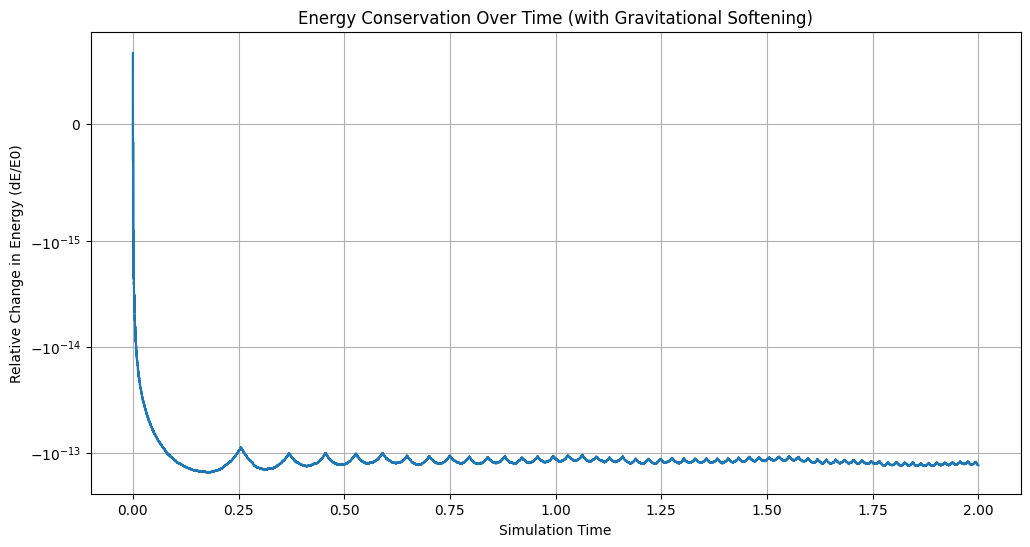

In [159]:
energy_history = []
for i in range(len(r_history)): # Loop over all steps in history
    # Use the stored r_history, v_history, theta_hist values for each step
    E = compute_energy(r_history[i], v_history[i], theta_hist[i])
    energy_history.append(E)

energy_history = np.array(energy_history)
dE_over_E0 = (energy_history - E0) / E0

plt.figure(figsize=(12, 6))
plt.plot(t_hist, dE_over_E0[1:]) # Plot dE/E0 (excluding initial step as E0 is reference)
plt.xlabel("Simulation Time")
plt.ylabel("Relative Change in Energy (dE/E0)")
plt.title("Energy Conservation Over Time (with Gravitational Softening)")
plt.grid(True)
plt.yscale('symlog', linthresh=1e-15) # Use symmetric log scale for better visualization of small changes
plt.show()

In [ ]:
# Re-run the simulation with the corrected physics
# (This cell is intentionally empty; the intent is for the user to execute the preceding modified d093def5 cell)

In [ ]:
# Plot theta_hist (rotation angle) over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, theta_hist[1:]) # Slice theta_hist to match t_hist length
plt.xlabel("Simulation Time")
plt.ylabel("Rotation Angle (radians)")
plt.title("Body 1 Rotation Angle Over Time (Tidal Bulge)")
plt.grid(True)
plt.show()

In [ ]:
# Plot omega_hist (spin rate) over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, omega_hist[1:]) # Slice omega_hist to match t_hist length
plt.xlabel("Simulation Time")
plt.ylabel("Spin Rate (radians/time unit)")
plt.title("Body 1 Spin Rate Over Time (Tidal Bulge)")
plt.grid(True)
plt.show()

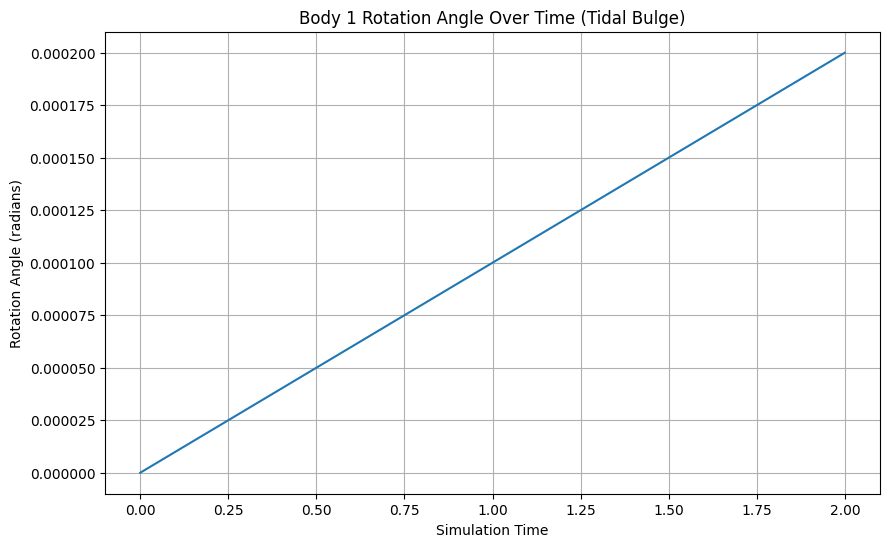

In [164]:
# Plot theta_hist (rotation angle) over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, theta_hist[1:]) # Slice theta_hist to match t_hist length
plt.xlabel("Simulation Time")
plt.ylabel("Rotation Angle (radians)")
plt.title("Body 1 Rotation Angle Over Time (Tidal Bulge)")
plt.grid(True)
plt.show()

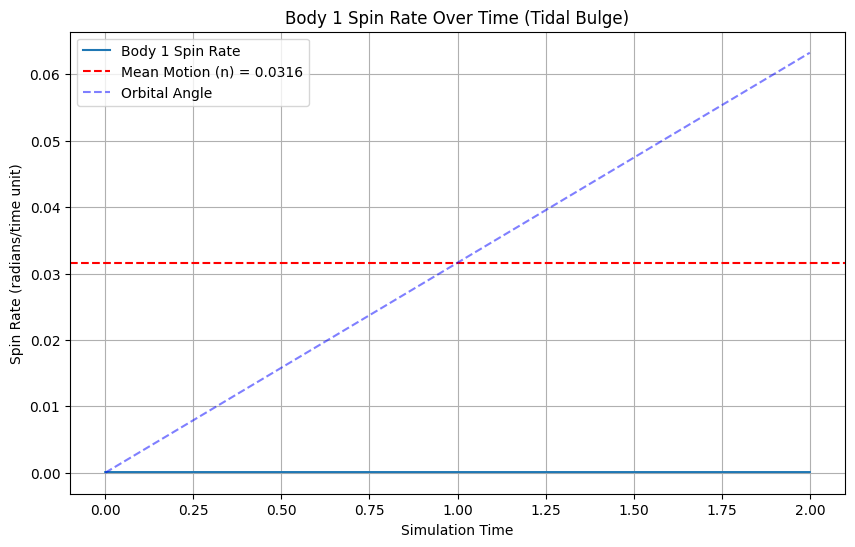

In [165]:
# Plot omega_hist (spin rate) over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, omega_hist[1:], label='Body 1 Spin Rate') # Slice omega_hist to match t_hist length
plt.xlabel("Simulation Time")
plt.ylabel("Spin Rate (radians/time unit)")
plt.title("Body 1 Spin Rate Over Time (Tidal Bulge)")
plt.grid(True)

# Check if locked: omega vs orbital mean motion n
mu = G * (m[0] + m[1])
# Ensure a_hist doesn't contain NaNs before computing mean
valid_a_hist = a_hist[~np.isnan(a_hist)]
if len(valid_a_hist) > 0:
    n = np.sqrt(mu / np.mean(valid_a_hist)**3) # mean motion
    plt.axhline(y=n, color='r', linestyle='--', label=f'Mean Motion (n) = {n:.4f}')
else:
    print("Warning: Cannot calculate mean motion as a_hist contains no valid values.")

# Add this after your plot
r_rel = r_history[:,1] - r_history[:,0]
orbital_angle = np.arctan2(r_rel[:,1], r_rel[:,0])

plt.plot(t_hist, orbital_angle[1:], 'b--', alpha=0.5, label='Orbital Angle')

plt.legend()
plt.show()

In [ ]:
# Plot theta_hist (rotation angle) over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, theta_hist[1:]) # Slice theta_hist to match t_hist length
plt.xlabel("Simulation Time")
plt.ylabel("Rotation Angle (radians)")
plt.title("Body 1 Rotation Angle Over Time (Tidal Bulge)")
plt.grid(True)
plt.show()

In [ ]:
# Plot omega_hist (spin rate) over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, omega_hist[1:]) # Slice omega_hist to match t_hist length
plt.xlabel("Simulation Time")
plt.ylabel("Spin Rate (radians/time unit)")
plt.title("Body 1 Spin Rate Over Time (Tidal Bulge)")
plt.grid(True)
plt.show()

In [ ]:
# Plot semi-major axis over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, a_hist)
plt.xlabel("Simulation Time")
plt.ylabel("Semi-major Axis (Simulation Units)")
plt.title("Semi-major Axis of Earth-Moon System Over Time")
plt.grid(True)
plt.show()

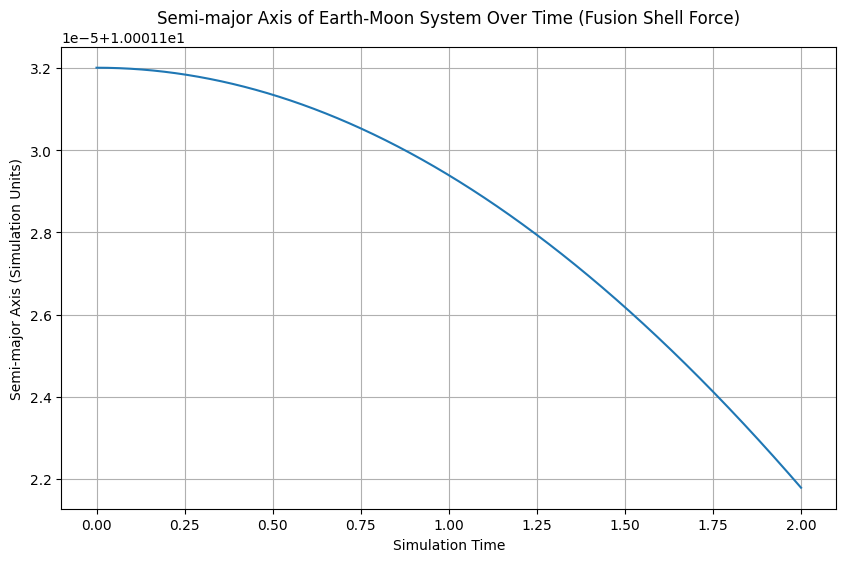

In [160]:
# Plot semi-major axis over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, a_hist)
plt.xlabel("Simulation Time")
plt.ylabel("Semi-major Axis (Simulation Units)")
plt.title("Semi-major Axis of Earth-Moon System Over Time (Fusion Shell Force)")
plt.grid(True)
plt.show()

In [ ]:
# Plot eccentricity over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, e_hist)
plt.xlabel("Simulation Time")
plt.ylabel("Eccentricity (Dimensionless)")
plt.title("Eccentricity of Earth-Moon System Over Time")
plt.grid(True)
plt.show()

In [ ]:
# Plot eccentricity over simulation time
plt.figure(figsize=(10, 6))
plt.plot(t_hist, e_hist)
plt.xlabel("Simulation Time")
plt.ylabel("Eccentricity (Dimensionless)")
plt.title("Eccentricity of Earth-Moon System Over Time (Fusion Shell Force)")
plt.grid(True)
plt.show()

Now, let's visualize the trajectories of the three bodies using a static plot.

In [ ]:
plt.figure(figsize=(10, 8))

# Plot trajectory for each body
for i in range(r_history.shape[1]): # Iterate through bodies
    plt.plot(r_history[:, i, 0], r_history[:, i, 1], label=f'Body {i+1}')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Trajectories of the Three Bodies')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal aspect ratio
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))

# Plot trajectory for each body
for i in range(r_history.shape[1]): # Iterate through bodies
    plt.plot(r_history[:, i, 0], r_history[:, i, 1], label=f'Body {i+1}')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Trajectories of the Three Bodies (Fusion Shell Force)')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal aspect ratio
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
for j in range(r_history.shape[1]):
    plt.plot(r_history[:, j, 0], r_history[:, j, 1], 'o-', lw=1, label=f'Body {j+1}')
plt.xlabel('X'); plt.ylabel('Y'); plt.legend(); plt.axis('equal'); plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
for j in range(r_history.shape[1]):
    plt.plot(r_history[:, j, 0], r_history[:, j, 1], 'o-', lw=1, label=f'Body {j+1}')
plt.xlabel('X'); plt.ylabel('Y'); plt.legend(); plt.axis('equal'); plt.grid(True)
plt.title('Trajectories of the Three Bodies (Fusion Shell Force - Detailed)')
plt.show()

Finally, let's create an animation to dynamically visualize the movement of the three bodies over time.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Increase animation embed limit to avoid 'Animation size' warning
plt.rcParams['animation.embed_limit'] = 200.0 # Set to 200 MB to accommodate larger animations

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Animated Trajectories of the Three Bodies')
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# Define a padding for the dynamic view around the center of mass
view_padding = 15.0 # Adjusted padding for dynamic view

# Create lines for each body
lines = [ax.plot([], [], 'o-', lw=2, label=f'Body {i+1}')[0] for i in range(r_history.shape[1])]
ax.legend()

# Initialization function: plot the background of each frame
def init():
    for line in lines:
        line.set_data([], [])
    return lines

# Animation function: this is called sequentially
def animate(i):
    # For each body, plot the trajectory up to the current frame 'i'
    for j, line in enumerate(lines):
        line.set_data(r_history[:i, j, 0], r_history[:i, j, 1])

    # Calculate center of mass for the current frame
    current_r = r_history[i]
    com = np.average(current_r, axis=0, weights=m)

    # Dynamically set the view limits around the center of mass
    ax.set_xlim(com[0] - view_padding, com[0] + view_padding)
    ax.set_ylim(com[1] - view_padding, com[1] + view_padding)

    return lines

# Create the animation
# `frames` is the number of frames, typically the number of steps in r_history
# `interval` is the delay between frames in ms
ani = animation.FuncAnimation(fig, animate, frames=len(r_history),
                              init_func=init, blit=True, interval=10)

# To display the animation in a Jupyter notebook or Colab
HTML(ani.to_jshtml())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Increase animation embed limit to avoid 'Animation size' warning
plt.rcParams['animation.embed_limit'] = 200.0 # Set to 200 MB to accommodate larger animations

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Animated Trajectories of the Three Bodies (Fusion Shell Force)')
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# Define a padding for the dynamic view around the center of mass
view_padding = 15.0 # Adjusted padding for dynamic view

# Create lines for each body
lines = [ax.plot([], [], 'o-', lw=2, label=f'Body {i+1}')[0] for i in range(r_history.shape[1])]
ax.legend()

# Initialization function: plot the background of each frame
def init():
    for line in lines:
        line.set_data([], [])
    return lines

# Animation function: this is called sequentially
def animate(i):
    # For each body, plot the trajectory up to the current frame 'i'
    for j, line in enumerate(lines):
        line.set_data(r_history[:i, j, 0], r_history[:i, j, 1])

    # Calculate center of mass for the current frame
    current_r = r_history[i]
    com = np.average(current_r, axis=0, weights=m)

    # Dynamically set the view limits around the center of mass
    ax.set_xlim(com[0] - view_padding, com[0] + view_padding)
    ax.set_ylim(com[1] - view_padding, com[1] + view_padding)

    return lines

# Create the animation
# `frames` is the number of frames, typically the number of steps in r_history
# `interval` is the delay between frames in ms
ani = animation.FuncAnimation(fig, animate, frames=len(r_history), init_func=init, blit=True, interval=10)

# To display the animation in a Jupyter notebook or Colab
HTML(ani.to_jshtml())

In [ ]:
# Downsampling factor: higher values mean fewer frames and a lighter animation
skip = 20 # Skip every 20 frames for a lighter animation

# Set up the figure and axes for the lightweight animation
fig_light, ax_light = plt.subplots(figsize=(10, 8))
ax_light.set_xlabel('X Position')
ax_light.set_ylabel('Y Position')
ax_light.set_title('Lightweight Animated Trajectories of the Three Bodies (Downsampled)')
ax_light.grid(True)
ax_light.set_aspect('equal', adjustable='box')

# Define a padding for the dynamic view around the center of mass
view_padding_light = 15.0 # Adjusted padding for dynamic view

# Create lines for each body for the lightweight animation
lines_light = [ax_light.plot([], [], 'o-', lw=2, label=f'Body {i+1}')[0] for i in range(r_history.shape[1])]
ax_light.legend()

# Animation function for downsampled frames
def animate_light(i):
    # Use downsampled history
    idx = i * skip
    if idx >= len(r_history): # Ensure we don't go out of bounds
        idx = len(r_history) - 1

    # For each body, plot the trajectory up to the current frame 'idx'
    for j, line in enumerate(lines_light):
        line.set_data(r_history[:idx, j, 0], r_history[:idx, j, 1])

    # Calculate center of mass for the current downsampled frame
    current_r = r_history[idx]
    com_light = np.average(current_r, axis=0, weights=m)

    # Dynamically set the view limits around the center of mass
    ax_light.set_xlim(com_light[0] - view_padding_light, com_light[0] + view_padding_light)
    ax_light.set_ylim(com_light[1] - view_padding_light, com_light[1] + view_padding_light)

    return lines_light

# Create the lightweight animation
# `frames` is now len(r_history) // skip to reflect downsampling
ani_light = animation.FuncAnimation(fig_light, animate_light, frames=len(r_history) // skip,
                                  init_func=init, blit=True, interval=50)

# Display the lightweight animation
HTML(ani_light.to_jshtml())

In [ ]:
# Downsampling factor: higher values mean fewer frames and a lighter animation
skip = 20 # Skip every 20 frames for a lighter animation

# Set up the figure and axes for the lightweight animation
fig_light, ax_light = plt.subplots(figsize=(10, 8))
ax_light.set_xlabel('X Position')
ax_light.set_ylabel('Y Position')
ax_light.set_title('Lightweight Animated Trajectories of the Three Bodies (Downsampled, Fusion Shell Force)')
ax_light.grid(True)
ax_light.set_aspect('equal', adjustable='box')

# Define a padding for the dynamic view around the center of mass
view_padding_light = 15.0 # Adjusted padding for dynamic view

# Create lines for each body for the lightweight animation
lines_light = [ax_light.plot([], [], 'o-', lw=2, label=f'Body {i+1}')[0] for i in range(r_history.shape[1])]
ax_light.legend()

# Animation function for downsampled frames
def animate_light(i):
    # Use downsampled history
    idx = i * skip
    if idx >= len(r_history): # Ensure we don't go out of bounds
        idx = len(r_history) - 1

    # For each body, plot the trajectory up to the current frame 'idx'
    for j, line in enumerate(lines_light):
        line.set_data(r_history[:idx, j, 0], r_history[:idx, j, 1])

    # Calculate center of mass for the current downsampled frame
    current_r = r_history[idx]
    com_light = np.average(current_r, axis=0, weights=m)

    # Dynamically set the view limits around the center of mass
    ax_light.set_xlim(com_light[0] - view_padding_light, com_light[0] + view_padding_light)
    ax_light.set_ylim(com_light[1] - view_padding_light, com_light[1] + view_padding_light)

    return lines_light

# Create the lightweight animation
# `frames` is now len(r_history) // skip to reflect downsampling
ani_light = animation.FuncAnimation(fig_light, animate_light, frames=len(r_history) // skip, init_func=init, blit=True, interval=50)

# Display the lightweight animation
HTML(ani_light.to_jshtml())

### Lightweight animation with downsampling

To address potential issues with large animation sizes and display performance, here's a version of the animation that uses downsampling. This means it only displays a subset of the simulated frames, making the animation lighter and faster to load, while still providing a good visual representation of the trajectories.